# Домашняя работа 2


In [6]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import MinMaxScaler

## Задание 1. Загрузка данных и проверка пропусков


In [7]:
df = pd.read_csv('heart.csv')
df.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,63,1,3,145,233,1,0,150,0,2.3,0,0,1,1
1,37,1,2,130,250,0,1,187,0,3.5,0,0,2,1
2,41,0,1,130,204,0,0,172,0,1.4,2,0,2,1
3,56,1,1,120,236,0,1,178,0,0.8,2,0,2,1
4,57,0,0,120,354,0,1,163,1,0.6,2,0,2,1


In [8]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 303 entries, 0 to 302
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       303 non-null    int64  
 1   sex       303 non-null    int64  
 2   cp        303 non-null    int64  
 3   trestbps  303 non-null    int64  
 4   chol      303 non-null    int64  
 5   fbs       303 non-null    int64  
 6   restecg   303 non-null    int64  
 7   thalach   303 non-null    int64  
 8   exang     303 non-null    int64  
 9   oldpeak   303 non-null    float64
 10  slope     303 non-null    int64  
 11  ca        303 non-null    int64  
 12  thal      303 non-null    int64  
 13  target    303 non-null    int64  
dtypes: float64(1), int64(13)
memory usage: 33.3 KB


In [9]:
df.isnull().sum()

age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          0
thal        0
target      0
dtype: int64

## Задание 2. Столбчатая диаграмма


In [10]:
counts = df['target'].value_counts()
print(counts)

target
1    165
0    138
Name: count, dtype: int64


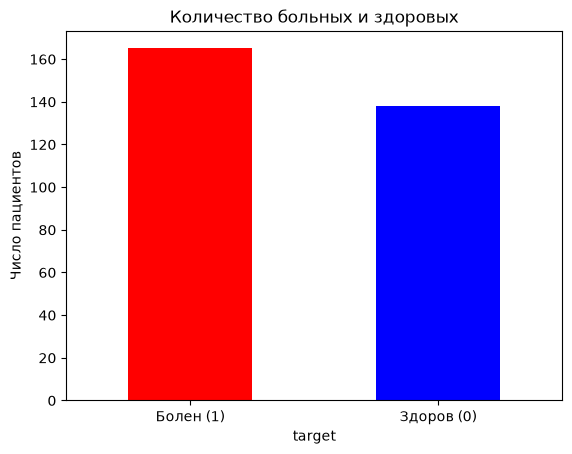

In [18]:
counts.plot(kind='bar', color=['red', 'blue'])
plt.title('Количество больных и здоровых')
plt.xticks([0, 1], ['Болен (1)', 'Здоров (0)'], rotation=0)
plt.ylabel('Число пациентов')
plt.show()

## Задание 3. Диаграмма рассеяния


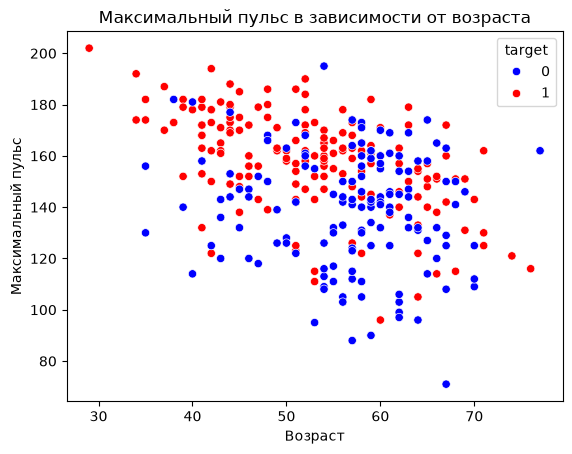

In [20]:
sns.scatterplot(data=df, x='age', y='thalach', hue='target',
                palette={0: 'blue', 1: 'red'})
plt.title('Максимальный пульс в зависимости от возраста')
plt.xlabel('Возраст')
plt.ylabel('Максимальный пульс')
plt.show()

## Задание 4. Преобразование признака sex и One-Hot Encoding


In [21]:
df['sex'] = df['sex'].map({0: 'female', 1: 'male'})
df['sex'].value_counts()

sex
male      207
female     96
Name: count, dtype: int64

In [22]:
df = pd.get_dummies(df, columns=['sex'], dtype=int)
df.head()

,age,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target,sex_female,sex_male
0,63,3,145,233,1,0,150,0,2.3,0,0,1,1,0,1
1,37,2,130,250,0,1,187,0,3.5,0,0,2,1,0,1
2,41,1,130,204,0,0,172,0,1.4,2,0,2,1,1,0
3,56,1,120,236,0,1,178,0,0.8,2,0,2,1,0,1
4,57,0,120,354,0,1,163,1,0.6,2,0,2,1,1,0


## Задание 5. Средний холестерин


In [23]:
df.groupby('target')['chol'].mean()

target
0    251.086957
1    242.230303
Name: chol, dtype: float64

## Задание 6. Нормализация признаков

In [26]:
cols = ['age', 'trestbps', 'chol', 'thalach']
scaler = MinMaxScaler()
df[cols] = scaler.fit_transform(df[cols])
df[cols].describe()

,age,trestbps,chol,thalach
count,303.000000,303.000000,303.000000,303.000000
mean,0.528465,0.354941,0.274575,0.600358
std,0.189210,0.165454,0.118335,0.174849
min,0.000000,0.000000,0.000000,0.000000
25%,0.385417,0.245283,0.194064,0.477099
50%,0.541667,0.339623,0.260274,0.625954
75%,0.666667,0.433962,0.339041,0.725191
max,1.000000,1.000000,1.000000,1.000000
